In [81]:
#Função que obtem dados de um periodo de tempo

In [3]:
#biblioteca para capturar os dados caso necessário
#!pip install yfinance

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 949.2/949.2 kB 892.0 kB/s eta 0:00:00B/s eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 4.2 MB/s eta 0:00:004.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 4.8 MB/s eta 0:00:000:00:01m eta 0:00:01
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15636 sha256=5b1b267a77ad9697f4b81a660df9a40d87349305966ed78b5a0d800fdf6b54a8
  Stored in directory: /home/valdeir/.cache/pip/wheels/1e/df/0f/e2bbb22d689b30c681feb5410ab64a2523437b34c8ecfc6476
  Created wheel for peewee: filename=peewee-3.18.2-py3-none-any.whl size=139106 sha256=7cb6efd0054af1de0f5a6c09270c305600e1ff07c6fed90bfc65c9bad06a07e6
  Store

In [5]:
#Importações
import yfinance as yf
from datetime import datetime
import pandas as pd
import os
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pickle

from sklearn.metrics import precision_score
from sklearn import svm

In [6]:
#Funções
def SalvarCsvYF(codigo_empresa, datainicial, datafinal, nomearquivo)->bool:
    try:
        dados = yf.Ticker(codigo_empresa)
        #dat.info
        d1 = datetime.strptime(datainicial,"%d/%m/%Y")
        d2 = datetime.strptime(datafinal,"%d/%m/%Y")
        objeto = dados.history(start = d1 , end = d2)
        objeto.to_json(nomearquivo)
        return True
    except Exception as e:
        print(e)
        return False

In [7]:
class Empresa:
    def __init__(self, nome ):
        self.nome = nome
        self.listaCSV = {}
        self.listaCSVTreinamento={}
        self.acumulodeanos = 0
        self.ano_teste = 0
        self.acuracy = -1
    def addArquivoCSV(self, arquivocsv): # já admiti que vai os dados na ordem 2020, 2020-2021, 2020-2022[..]
        self.ano_teste += 1
        self.listaCSV[self.ano_teste] = arquivocsv
    def addArquivoCSVTreinamento(self, arquivocsv): # já admiti que vai os dados na ordem 2020, 2020-2021, 2020-2022[..]
        self.acumulodeanos += 1
        self.listaCSVTreinamento[self.acumulodeanos] = arquivocsv
    def keys(self):
        return self.listaCSV.keys()
    def obterNumeroCSV(self):
        self.acumulodeanos
    def obterIndex(self, index):
        return self.listaCSV[index]
    def obterIndexTreinamento(self, index):
        return self.listaCSVTreinamento[index]
    

In [8]:
#empresas = ["BBAS3.SA","ITSA4.SA", "BPAC11.SA", "ITUB4.SA", "SANB11.SA"]
empresas = ["BBAS3.SA"]
anos = [ 2019 , 2020, 2021, 2022, 2023, 2024 ]
listaEmpresa = []

for empresa in empresas:
    novaempresa = Empresa(empresa)
    #Dados treinamento
    for ano in anos[:-1]:
        if anos[0] == ano:
            arquivocsv = empresa+"_"+str(ano) + "_Treino.json"
        if anos[0] != ano:
            arquivocsv =  empresa+"_"+str(anos[0])+"-"+ str(ano) + "_Treino.json"
        if not os.path.exists(arquivocsv):
            SalvarCsvYF(empresa, "01/01/"+str(anos[0]) , "31/12/"+str(ano), arquivocsv)
        novaempresa.addArquivoCSVTreinamento(arquivocsv)
    for ano in anos[1:]:
        arquivocsv = empresa+"_"+str(ano) + "_Teste.json"
        if not os.path.exists(arquivocsv):
            SalvarCsvYF(empresa, "01/01/"+str(anos[0]) , "31/12/"+str(ano), arquivocsv)
        novaempresa.addArquivoCSV(arquivocsv)    
    listaEmpresa.append(novaempresa)



In [9]:
def ObterAcuraciaModelForestClassifier(arquivo):
    historico = pd.read_json(arquivo)
    cabecalho = ["Close", "Volume", "Open", "High", "Low"]
    data = historico[["Close"]]
    data = data.rename(columns = {'Close':'Actual_Close'})
    data["Target"] = historico.rolling(2).apply(lambda x: x.iloc[1] > x.iloc[0])["Close"]
    data.head()
    prehist = historico.copy()
    prehist = prehist.shift(1)
    cabecalho = ["Close", "Volume", "Open", "High", "Low"]
    data = data.join(prehist[cabecalho]).iloc[1:]
    model = RandomForestClassifier(n_estimators=100, min_samples_split=200, random_state=1)
    data2 = data["Target"]
    train =data.iloc[:-100]
    test = data.iloc[-100:]
    model.fit(train[cabecalho], train["Target"])
    predicao = model.predict( test[cabecalho])
    predicao = pd.Series(predicao,index=test.index)
    accuracy = precision_score( test["Target"], predicao)
    return accuracy, model
    

In [10]:
def ObterAcuraciaModelSVM(arquivo):
    historico = pd.read_json(arquivo)
    cabecalho = ["Close", "Volume", "Open", "High", "Low"]
    data = historico[["Close"]]
    data = data.rename(columns = {'Close':'Actual_Close'})
    data["Target"] = historico.rolling(2).apply(lambda x: x.iloc[1] > x.iloc[0])["Close"]
    #print(data["Target"])
    #data.head()
    
    prehist = historico.copy()
    prehist = prehist.shift(1)
    cabecalho = ["Close", "Volume", "Open", "High", "Low"]
    data = data.join(prehist[cabecalho]).iloc[1:]
    model = svm.SVC()
    train = data.iloc[:-100]
    test = data.iloc[-100:]
    model = model.fit(train[cabecalho], train["Target"])
    predicao = model.predict( test[cabecalho])
    predicao = pd.Series(predicao,index=test.index)
    #predicao.plot.line(y="Close", use_index=True)
    accuracy = precision_score( test["Target"], predicao)
    return accuracy, model
    

In [11]:
def TestaModelo( modelo, arquivo):
    historico = pd.read_json(arquivo)
    cabecalho = ["Close", "Volume", "Open", "High", "Low"]
    data = historico[["Close"]]
    data = data.rename(columns = {'Close':'Actual_Close'})
    data["Target"] = historico.rolling(2).apply(lambda x: x.iloc[1] > x.iloc[0])["Close"]
    
    
    #print(data["Target"])
    #data.head()
    #exit
    prehist = historico.copy()
    prehist = prehist.shift(1)
    cabecalho = ["Close", "Volume", "Open", "High", "Low"]
    data = data.join(prehist[cabecalho]).iloc[1:]
    
    print(f"Dados do teste")
    print(data[["Actual_Close","Target"]].head(10))
    #print(historico.head(5))
    #print(data.head(5))
    #model = svm.SVC()
    #train = data.iloc[:-100]
    #test = data.iloc[-100:]
    #model.fit(train[cabecalho], train["Target"])
    predicao = model.predict( data[cabecalho])
    predicao = pd.Series(predicao,index=data.index)
    #predicao.plot.line(y="Close", use_index=True)
    accuracy = precision_score( data["Target"], predicao)
    print("\n\n\n")
    return accuracy

In [12]:
def obtemdfArquivo(arquivo):
	historico = pd.read_json(arquivo)
	cabecalho = ["Close", "Volume", "Open", "High", "Low"]
	data = historico[["Close"]]
	data = data.rename(columns = {'Close':'Actual_Close'})
	data["Target"] = historico.rolling(2).apply(lambda x: x.iloc[1] > x.iloc[0])["Close"]
	prehist = historico.copy()
	prehist = prehist.shift(1)
	cabecalho = ["Close", "Volume", "Open", "High", "Low"]
	data = data.join(prehist[cabecalho]).iloc[1:]
	return data

In [13]:
for empresa in listaEmpresa:
    print("------------------------------------------------------------------------")
    print(f"Empresa: {empresa.nome}")
    print("************************************************************************")
    for i in empresa.keys():
        arquivo = empresa.obterIndexTreinamento(i)
        #pred, model = ObterAcuraciaModelSVM(arquivo)
        arquivodat = arquivo + "ForestClassifier.dat"
        arquivopred = arquivo + "ForestClassifier.pred"
        if os.path.exists(arquivodat) and os.path.exists(arquivopred):
            print("Carregando modelo e resultados processados...")
            with open(arquivodat, 'rb') as file:
                model = pickle.load(file)
            with open(arquivopred,"r") as file2:
                pred = file2.read()
        else:
            print("Gerando modelo e processando dados...")
            pred, model = ObterAcuraciaModelForestClassifier(arquivo)
            with open(arquivodat, 'wb') as file:
                pickle.dump(model, file)
            file2 = open(arquivopred, "w")
            file2.write(str(pred))
            file2.close()
        print(f"accuracy {pred} {arquivo}")
        
        
        accuracy = TestaModelo(model, arquivo)
        print(f"O dados {empresa.obterIndex(i)} teve perfomace {accuracy}")
        print("")
    print("************************************************************************")

------------------------------------------------------------------------
Empresa: BBAS3.SA
************************************************************************
Carregando modelo e resultados processados...
accuracy 0.46 BBAS3.SA_2019_Treino.json
Dados do teste
                     Actual_Close  Target
2019-01-03 02:00:00     16.293253     1.0
2019-01-04 02:00:00     16.293253     0.0
2019-01-07 02:00:00     16.186417     0.0
2019-01-08 02:00:00     16.002783     0.0
2019-01-09 02:00:00     15.959384     0.0
2019-01-10 02:00:00     16.193094     1.0
2019-01-11 02:00:00     16.259872     1.0
2019-01-14 02:00:00     16.637157     1.0
2019-01-15 02:00:00     16.443502     0.0
2019-01-16 02:00:00     16.286577     0.0




O dados BBAS3.SA_2020_Teste.json teve perfomace 0.4979757085020243

Carregando modelo e resultados processados...
accuracy 0.5135135135135135 BBAS3.SA_2019-2020_Treino.json


/home/valdeir/UEM/ProjetosUEM/Igarashi/ambientevirtual/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/valdeir/UEM/ProjetosUEM/Igarashi/ambientevirtual/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/valdeir/UEM/ProjetosUEM/Igarashi/ambientevirtual/lib/python3.13/site-packages/sklearn/base.py:442: Incon

Dados do teste
                     Actual_Close  Target
2019-01-03 02:00:00     16.293255     1.0
2019-01-04 02:00:00     16.293255     0.0
2019-01-07 02:00:00     16.186420     0.0
2019-01-08 02:00:00     16.002783     0.0
2019-01-09 02:00:00     15.959380     0.0
2019-01-10 02:00:00     16.193096     1.0
2019-01-11 02:00:00     16.259867     1.0
2019-01-14 02:00:00     16.637156     1.0
2019-01-15 02:00:00     16.443499     0.0
2019-01-16 02:00:00     16.286581     0.0




O dados BBAS3.SA_2021_Teste.json teve perfomace 0.5765765765765766

Carregando modelo e resultados processados...
accuracy 0.4807692307692308 BBAS3.SA_2019-2021_Treino.json


/home/valdeir/UEM/ProjetosUEM/Igarashi/ambientevirtual/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/valdeir/UEM/ProjetosUEM/Igarashi/ambientevirtual/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Dados do teste
                     Actual_Close  Target
2019-01-03 02:00:00     16.293257     1.0
2019-01-04 02:00:00     16.293257     0.0
2019-01-07 02:00:00     16.186417     0.0
2019-01-08 02:00:00     16.002781     0.0
2019-01-09 02:00:00     15.959380     0.0
2019-01-10 02:00:00     16.193102     1.0
2019-01-11 02:00:00     16.259869     1.0
2019-01-14 02:00:00     16.637154     1.0
2019-01-15 02:00:00     16.443501     0.0
2019-01-16 02:00:00     16.286573     0.0




O dados BBAS3.SA_2022_Teste.json teve perfomace 0.6177285318559557

Carregando modelo e resultados processados...
accuracy 0.532258064516129 BBAS3.SA_2019-2022_Treino.json


/home/valdeir/UEM/ProjetosUEM/Igarashi/ambientevirtual/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/valdeir/UEM/ProjetosUEM/Igarashi/ambientevirtual/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Dados do teste
                     Actual_Close  Target
2019-01-03 02:00:00     16.293257     1.0
2019-01-04 02:00:00     16.293257     0.0
2019-01-07 02:00:00     16.186413     0.0
2019-01-08 02:00:00     16.002781     0.0
2019-01-09 02:00:00     15.959380     0.0
2019-01-10 02:00:00     16.193087     1.0
2019-01-11 02:00:00     16.259876     1.0
2019-01-14 02:00:00     16.637152     1.0
2019-01-15 02:00:00     16.443508     0.0
2019-01-16 02:00:00     16.286575     0.0




O dados BBAS3.SA_2023_Teste.json teve perfomace 0.6546184738955824

Carregando modelo e resultados processados...
accuracy 0.5294117647058824 BBAS3.SA_2019-2023_Treino.json


/home/valdeir/UEM/ProjetosUEM/Igarashi/ambientevirtual/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/valdeir/UEM/ProjetosUEM/Igarashi/ambientevirtual/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Dados do teste
                     Actual_Close  Target
2019-01-03 02:00:00     16.293255     1.0
2019-01-04 02:00:00     16.293255     0.0
2019-01-07 02:00:00     16.186419     0.0
2019-01-08 02:00:00     16.002783     0.0
2019-01-09 02:00:00     15.959376     0.0
2019-01-10 02:00:00     16.193096     1.0
2019-01-11 02:00:00     16.259863     1.0
2019-01-14 02:00:00     16.637152     1.0
2019-01-15 02:00:00     16.443506     0.0
2019-01-16 02:00:00     16.286585     0.0




O dados BBAS3.SA_2024_Teste.json teve perfomace 0.6887096774193548

************************************************************************


In [10]:
for empresa in listaEmpresa:
    print("------------------------------------------------------------------------")
    print(f"Empresa: {empresa.nome}")
    print("************************************************************************")
    for i in empresa.keys():
        arquivo = empresa.obterIndexTreinamento(i)
        #pred, model = ObterAcuraciaModelSVM(arquivo)
        arquivodat = arquivo + "SVM.dat"
        arquivopred = arquivo + "SVM.pred"
        if os.path.exists(arquivodat) and os.path.exists(arquivopred):
            print("Carregando modelo...")
            with open(arquivodat, 'rb') as file:
                model = pickle.load(file)
            with open(arquivopred,"r") as file2:
                pred = file2.read()
        else:
            print("Gerando modelo...")
            pred, model = ObterAcuraciaModelSVM(arquivo)
            with open(arquivodat, 'wb') as file:
                pickle.dump(model, file)
            file2 = open(arquivopred, "w")
            file2.write(str(pred))
            file2.close()
        print(f"accuracy {pred} {arquivo}")

        
        accuracy = TestaModelo(model, arquivo)
        print(f"O dados {empresa.obterIndex(i)} teve perfomace {accuracy}")
        print("")
    print("************************************************************************")

------------------------------------------------------------------------
Empresa: BBAS3.SA
************************************************************************
Gerando modelo...
accuracy 0.46 BBAS3.SA_2019_Treino.json
Dados do teste
                         Close      Volume       Open       High        Low
2019-01-03 02:00:00  16.226482  29810600.0  15.425175  16.593749  15.388449
2019-01-04 02:00:00  16.293253  17758200.0  16.193090  16.426805  15.976068
2019-01-07 02:00:00  16.293253  17718400.0  16.052862  16.637148  15.999440
2019-01-08 02:00:00  16.186417  18787000.0  16.303275  16.516957  16.082914
2019-01-09 02:00:00  16.002783  29034600.0  16.226481  16.376726  15.635517




O dados BBAS3.SA_2020_Teste.json teve perfomace 0.4979757085020243

Gerando modelo...
accuracy 0.6666666666666666 BBAS3.SA_2019-2020_Treino.json
Dados do teste
                         Close      Volume       Open       High        Low
2019-01-03 02:00:00  16.226482  29810600.0  15.425175  16.593749  1

In [11]:
def simulacao(modelo, arquivoteste):
    capinicial = 100000
    capital_atual = 0
    acoes_em_carteira = 0
    historico_transacoes = []
    modelo_ml_treinado = []
    dados_de_teste = []
    validacao = []

In [12]:
#!pip install matplotlib

<Axes: >

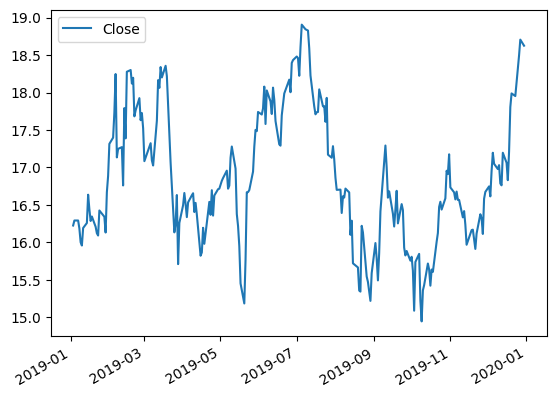

In [16]:
arquivo = 'BBAS3.SA_2021_Teste.json'
arquivodat = 'BBAS3.SA_2019_Treino.json'
dados = obtemdfArquivo(arquivodat)
dados.plot.line(y="Close", use_index=True)

In [17]:

#with open(arquivodat, 'rb') as file:
#    modelo = pickle.load(file)
acuracia ,modelo = ObterAcuraciaModelForestClassifier(arquivodat)
cabecalho = ["Close", "Volume", "Open", "High", "Low"]
resultados = []

for i in range(len(dados)):
    registro = dados[cabecalho].iloc[[i]]
    print("registro -> ", registro)
    #registro = dados[cabecalho].tail(i)
    #print(registro)
    pred = modelo.predict(registro)
    resultados.append(pred)
#print(resultados)
for i in resultados:
    print(i)

registro ->                           Close      Volume       Open       High        Low
2019-01-03 02:00:00  16.226482  29810600.0  15.425175  16.593749  15.388449
registro ->                           Close      Volume      Open       High        Low
2019-01-04 02:00:00  16.293253  17758200.0  16.19309  16.426805  15.976068
registro ->                           Close      Volume       Open       High       Low
2019-01-07 02:00:00  16.293253  17718400.0  16.052862  16.637148  15.99944
registro ->                           Close      Volume       Open       High        Low
2019-01-08 02:00:00  16.186417  18787000.0  16.303275  16.516957  16.082914
registro ->                           Close      Volume       Open       High        Low
2019-01-09 02:00:00  16.002783  29034600.0  16.226481  16.376726  15.635517
registro ->                           Close      Volume       Open       High        Low
2019-01-10 02:00:00  15.959384  33436000.0  16.143017  16.143017  15.852543
registro ->   